<a href="https://colab.research.google.com/github/graceputu1-sys/Individual-Project/blob/main/1st_of_September_PiP_Final_Project_2026_Grace.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Create a new text file named 'my_project_file.txt' and write content into it
with open("my_project_file.txt", "w") as file:
    file.write("Hello! This is a file created in my Colab project.")

print("File created and written successfully!")

File created and written successfully!


In [ ]:
print("The files you selected are already available in the Colab environment.")
print("Files found:")
print("  - /content/pip_cases_2018_2025 (1).xlsx")
print("  - /content/PIP_Clearances_2018-2025 (1).xlsx")
print("  - /content/PIP_MR_Clearances_2018-2025 (1) (1).xlsx")

The files you selected are already available in the Colab environment.
Files found:
  - /content/pip_cases_2018_2025 (1).xlsx
  - /content/PIP_Clearances_2018-2025 (1).xlsx
  - /content/PIP_MR_Clearances_2018-2025 (1) (1).xlsx


In [ ]:
# ── INSTALL LIBRARIES ─────────────────────────────────────────────────────────
!pip install openpyxl statsmodels scipy matplotlib seaborn -q

import openpyxl, pandas as pd, numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')


In [ ]:
# ── LOADER FOR CASES FILE ─────────────────────────────────────────────────────
def load_cases(filepath):
    wb   = openpyxl.load_workbook(filepath, read_only=True)
    rows = list(wb.active.iter_rows(values_only=True))

    # Debugging: Print a few initial rows to understand structure
    print(f"\n--- Debugging load_cases for: {filepath} ---")
    print("First 5 rows:")
    for i, row in enumerate(rows[:5]):
        print(f"Row {i}: {row}")

    hdr_found = False
    hdr = -1
    for i,r in enumerate(rows):
        # Correctly identify header using 'Month' in first column
        if r and r[0]=='Month':
            hdr = i
            hdr_found = True
            break

    if not hdr_found:
        print("Header 'Month' not found in any row.")
        return pd.DataFrame() # Return empty DataFrame if header not found

    print(f"Header 'Month' found at row index: {hdr}")
    # Months are correctly extracted starting from the second element of the header row
    months = [v for v in rows[hdr] if v is not None][1:]
    print(f"Extracted months (first 5): {months[:5]}")

    data = {}
    row_count = 0
    for i, row in enumerate(rows[hdr+1:]):
        if i < 5: # Debug first 5 data rows
            print(f"Processing data row {hdr+1+i}: {row}")

        # Change: Check row[1] for label presence instead of row[0]
        if row[1] is None:
            if i < 5: print("  Skipping: row[1] is None")
            continue

        # Change: Extract label from row[1]
        label = str(row[1]).strip()
        if label in ('Total','INFO','',
                     'Disability not recorded - Assessment not completed'):
            if i < 5: print(f"  Skipping: Label '{label}' in skip list")
            continue

        # Change: Adjust vals slice to start from row[2] as label is in row[1]
        vals = [float(v) if isinstance(v,(int,float)) else np.nan
                for v in row[2:len(months)+2]]

        if any(not np.isnan(v) for v in vals):
            data[label] = vals
            row_count += 1
            if i < 5: print(f"  Added label '{label}' with {len(vals)} values.")
        else:
            if i < 5: print(f"  Skipping: No valid numeric data for label '{label}'")

    # Added robust debugging here
    print(f"\n--- Debugging load_cases end for: {filepath} ---")
    print(f"Final row_count: {row_count}")
    print(f"Final data keys (first 5): {list(data.keys())[:5] if data else []}")

    if not data:
        print("No data collected after processing all rows. Returning empty DataFrame.")
        return pd.DataFrame()

    print(f"Returning DataFrame with shape ({len(data)}, {len(months)})\n")
    return pd.DataFrame(data, index=months).T

In [ ]:
# ── LOADER FOR MR AND CLEARANCES FILES ───────────────────────────────────────
def load_statxplore(filepath):
    wb   = openpyxl.load_workbook(filepath, read_only=True)
    rows = list(wb.active.iter_rows(values_only=True))
    hdr  = next(i for i,r in enumerate(rows) if r[0]=='Month')
    months = [v for v in rows[hdr] if v is not None][1:]
    data = {}
    for row in rows[hdr+2:]:
        if row[1] is None: continue
        label = str(row[1]).strip()
        if label in ('Total','INFO','',
                     'Disability not recorded - Assessment not completed'): continue
        vals = [float(v) if isinstance(v,(int,float)) else np.nan
                for v in row[2:len(months)+2]]
        if any(not np.isnan(v) for v in vals):
            data[label] = vals
    return pd.DataFrame(data, index=months).T


In [ ]:
# ── LOAD ALL THREE FILES ──────────────────────────────────────────────────────
cases = load_cases('/content/pip_cases_2018_2025 (1).xlsx')
mr    = load_statxplore('/content/PIP_MR_Clearances_2018-2025 (1) (1).xlsx')
cl    = load_statxplore('/content/PIP_Clearances_2018-2025 (1).xlsx')

print("Cases loaded:", cases.shape)
print("MR loaded:", mr.shape)
print("Clearances loaded:", cl.shape)
print("Cases months:", cases.columns[0], "to", cases.columns[-1])


--- Debugging load_cases for: /content/pip_cases_2018_2025 (1).xlsx ---
First 5 rows:
Row 0: ('PIP Cases with Entitlement, 2018-2025', None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None)
Row 1: ('Disability by Month', None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None,

In [ ]:
# ── CONDITION GROUPS ──────────────────────────────────────────────────────────
invisible = ['Psychiatric disorders',
             'Musculoskeletal disease (general)',
             'Musculoskeletal disease (regional)',
             'Autoimmune disease (connective tissue disorders)']

visible   = ['Neurological disease',
             'Visual disease',
             'Hearing disorders',
             'Cardiovascular disease']


In [ ]:
# ── FILTER TO JAN 2018 TO DEC 2025 ───────────────────────────────────────────
valid = [c for c in cases.columns
         if pd.to_datetime(c, format='%b-%y') <= pd.Timestamp('2025-12-01')]
cases = cases[valid]
mr    = mr[valid]
cl    = cl[valid]
print("Months retained:", len(valid), "| From:", valid[0], "To:", valid[-1])


Months retained: 96 | From: Jan-18 To: Dec-25


In [ ]:
# ── QUARTERLY AGGREGATION ─────────────────────────────────────────────────────
def to_quarterly(df):
    print(f"\n--- Debugging to_quarterly for DataFrame with shape: {df.shape} ---")
    print(f"Initial columns (first 5): {list(df.columns[:5])}")

    df2 = df.copy()
    # Convert columns to datetime objects for resampling, coercing errors
    datetime_columns = pd.to_datetime(df.columns, format='%b-%y', errors='coerce')

    # Filter out NaT (Not a Time) values, which correspond to non-date columns
    valid_datetime_columns = datetime_columns.dropna()
    valid_original_columns = df.columns[datetime_columns.notna()]

    df2 = df2[valid_original_columns] # Keep only the columns that could be converted to datetime
    df2.columns = valid_datetime_columns

    print(f"Columns after datetime conversion and filtering (first 5): {list(df2.columns[:5])}")
    print(f"Shape after column conversion and filtering: {df2.shape}")

    # Transpose, resample to quarterly mean, then transpose back
    resampled_df = df2.T.resample('QS').mean().T

    print(f"Shape after resampling: {resampled_df.shape}")
    print(f"Resampled columns (first 5): {list(resampled_df.columns[:5]) if not resampled_df.empty else 'Empty'}")
    print("--- End Debugging to_quarterly ---\n")
    return resampled_df

cq = to_quarterly(cases)
mq = to_quarterly(mr)
lq = to_quarterly(cl)
print("Quarterly periods:", len(cq.columns),
      "| From:", cq.columns[0].strftime('%b-%Y'),
      "To:", cq.columns[-1].strftime('%b-%Y'))


--- Debugging to_quarterly for DataFrame with shape: (21, 96) ---
Initial columns (first 5): ['Jan-18', 'Feb-18', 'Mar-18', 'Apr-18', 'May-18']
Columns after datetime conversion and filtering (first 5): [Timestamp('2018-01-01 00:00:00'), Timestamp('2018-02-01 00:00:00'), Timestamp('2018-03-01 00:00:00'), Timestamp('2018-04-01 00:00:00'), Timestamp('2018-05-01 00:00:00')]
Shape after column conversion and filtering: (21, 96)
Shape after resampling: (21, 32)
Resampled columns (first 5): [Timestamp('2018-01-01 00:00:00'), Timestamp('2018-04-01 00:00:00'), Timestamp('2018-07-01 00:00:00'), Timestamp('2018-10-01 00:00:00'), Timestamp('2019-01-01 00:00:00')]
--- End Debugging to_quarterly ---


--- Debugging to_quarterly for DataFrame with shape: (21, 97) ---
Initial columns (first 5): ['Jan-18', 'Feb-18', 'Mar-18', 'Apr-18', 'May-18']
Columns after datetime conversion and filtering (first 5): [Timestamp('2018-01-01 00:00:00'), Timestamp('2018-02-01 00:00:00'), Timestamp('2018-03-01 00:00:0

In [ ]:
# ── GROUP TOTALS ──────────────────────────────────────────────────────────────
inv_c = cq.loc[invisible].sum()
vis_c = cq.loc[visible].sum()
inv_m = mq.loc[invisible].sum()
vis_m = mq.loc[visible].sum()
inv_l = lq.loc[invisible].sum()
vis_l = lq.loc[visible].sum()

inv_mr_rate = (inv_m / inv_c * 1000).dropna()
vis_mr_rate = (vis_m / vis_c * 1000).dropna()
inv_cl_rate = (inv_l / inv_c * 1000).dropna()
vis_cl_rate = (vis_l / vis_c * 1000).dropna()
quarters    = cq.columns

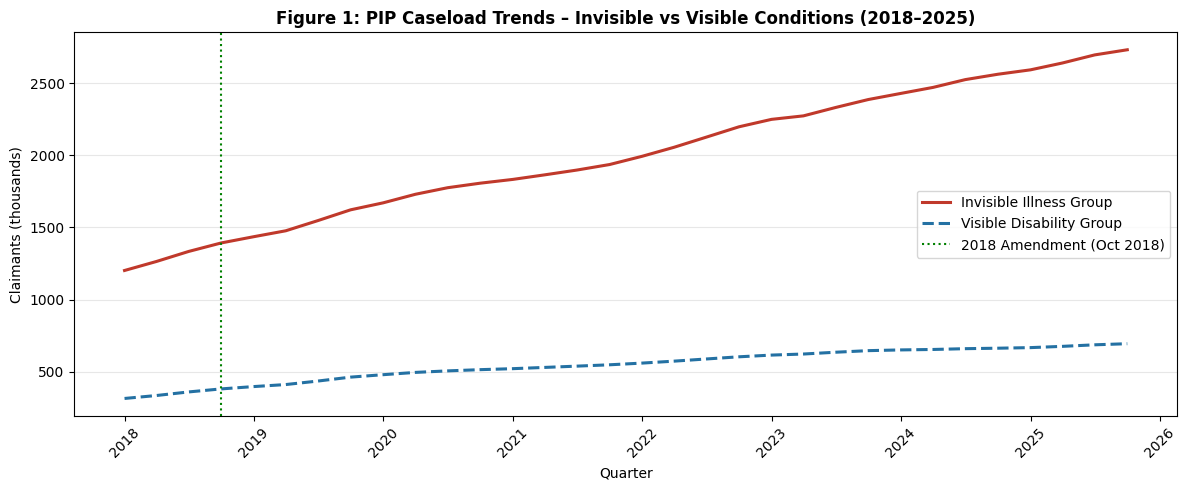

Figure 1 complete


In [ ]:
# FIGURE 1 — CASELOAD TRENDS 2018-2025
# ══════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(12,5))
ax.plot(quarters, inv_c/1000, color='#C0392B', lw=2.2,
        label='Invisible Illness Group')
ax.plot(quarters, vis_c/1000, color='#2471A3', lw=2.2, ls='--',
        label='Visible Disability Group')
ax.axvline(pd.Timestamp('2018-10-01'), color='green', ls=':', lw=1.5,
           label='2018 Amendment (Oct 2018)')
ax.set_title('Figure 1: PIP Caseload Trends – Invisible vs Visible Conditions (2018–2025)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Quarter')
ax.set_ylabel('Claimants (thousands)')
ax.legend()
ax.tick_params(axis='x', rotation=45)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('Figure1_Caseload.png', dpi=180, bbox_inches='tight')
plt.show()
print("Figure 1 complete")



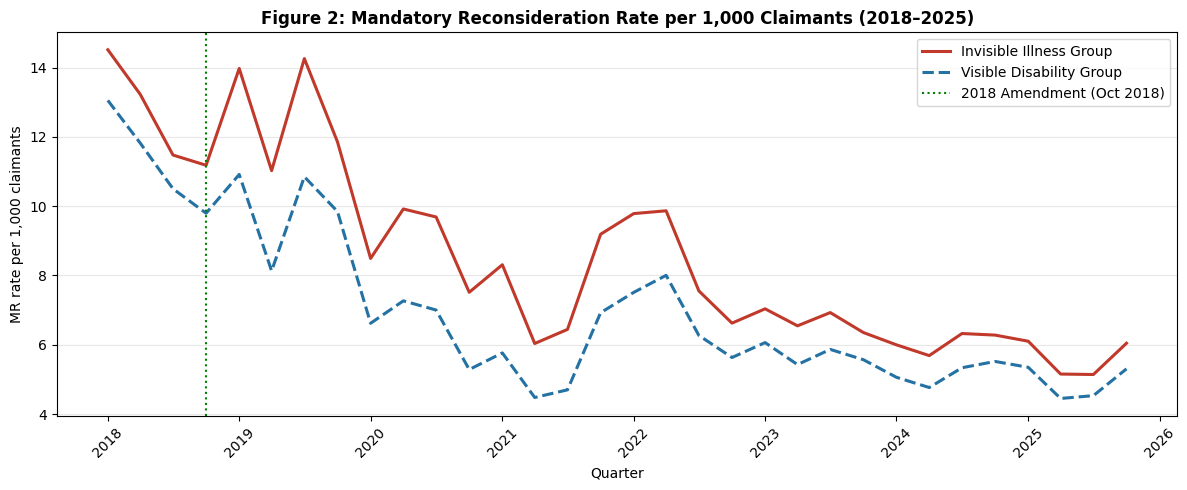

Figure 2 complete


In [ ]:
# FIGURE 2 — MR RATE TRENDS 2018-2025
# ══════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(12,5))
ax.plot(inv_mr_rate.index, inv_mr_rate.values, color='#C0392B', lw=2.2,
        label='Invisible Illness Group')
ax.plot(vis_mr_rate.index, vis_mr_rate.values, color='#2471A3', lw=2.2, ls='--',
        label='Visible Disability Group')
ax.axvline(pd.Timestamp('2018-10-01'), color='green', ls=':', lw=1.5,
           label='2018 Amendment (Oct 2018)')
ax.set_title('Figure 2: Mandatory Reconsideration Rate per 1,000 Claimants (2018–2025)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Quarter')
ax.set_ylabel('MR rate per 1,000 claimants')
ax.legend()
ax.tick_params(axis='x', rotation=45)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('Figure2_MR_Rate.png', dpi=180, bbox_inches='tight')
plt.show()
print("Figure 2 complete")



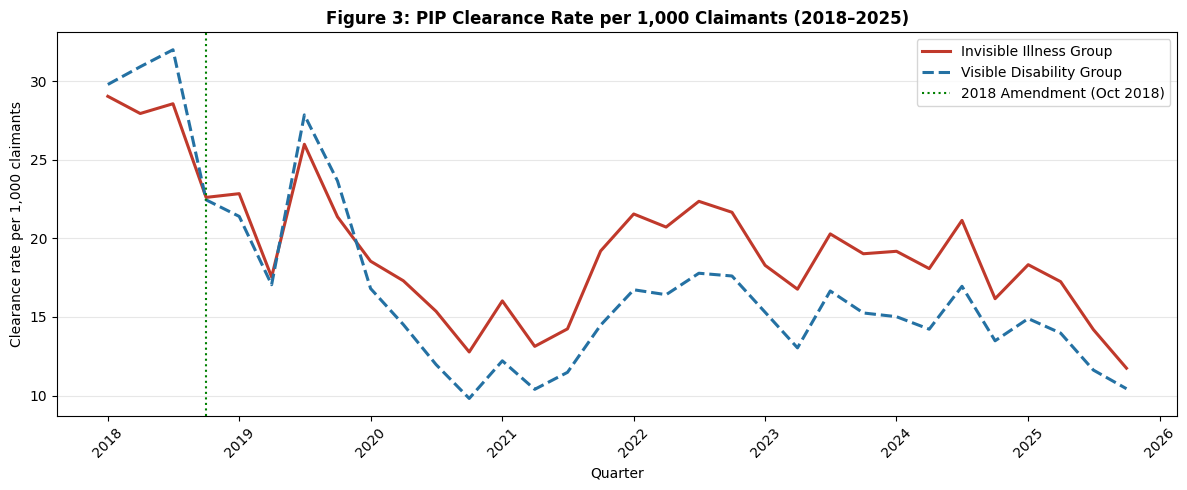

Figure 3 complete


In [ ]:
# FIGURE 3 — CLEARANCE RATE TRENDS 2018-2025
# ══════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(12,5))
ax.plot(inv_cl_rate.index, inv_cl_rate.values, color='#C0392B', lw=2.2,
        label='Invisible Illness Group')
ax.plot(vis_cl_rate.index, vis_cl_rate.values, color='#2471A3', lw=2.2, ls='--',
        label='Visible Disability Group')
ax.axvline(pd.Timestamp('2018-10-01'), color='green', ls=':', lw=1.5,
           label='2018 Amendment (Oct 2018)')
ax.set_title('Figure 3: PIP Clearance Rate per 1,000 Claimants (2018–2025)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Quarter')
ax.set_ylabel('Clearance rate per 1,000 claimants')
ax.legend()
ax.tick_params(axis='x', rotation=45)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('Figure3_Clearance.png', dpi=180, bbox_inches='tight')
plt.show()
print("Figure 3 complete")



In [ ]:
# CHI-SQUARE TESTS
# ══════════════════════════════════════════════════════════════════════════════
inv_m_tot = float(inv_m.sum())
vis_m_tot = float(vis_m.sum())
inv_c_tot = float(inv_c.sum())
vis_c_tot = float(vis_c.sum())
inv_l_tot = float(inv_l.sum())
vis_l_tot = float(vis_l.sum())

ct_mr = np.array([[inv_m_tot, vis_m_tot],
                   [inv_c_tot - inv_m_tot, vis_c_tot - vis_m_tot]])
chi2_mr, p_mr, dof_mr, _ = chi2_contingency(ct_mr)
or_mr = (inv_m_tot*(vis_c_tot-vis_m_tot)) / (vis_m_tot*(inv_c_tot-inv_m_tot))

ct_cl = np.array([[inv_l_tot, vis_l_tot],
                   [inv_c_tot - inv_l_tot, vis_c_tot - vis_l_tot]])
chi2_cl, p_cl, dof_cl, _ = chi2_contingency(ct_cl)
or_cl = (inv_l_tot*(vis_c_tot-vis_l_tot)) / (vis_l_tot*(inv_c_tot-inv_l_tot))

print("\n=== CHI-SQUARE RESULTS ===")
print(f"MR Test:        chi2={chi2_mr:.2f}, df={dof_mr}, p={p_mr:.2e}, OR={or_mr:.3f}")
print(f"Clearance Test: chi2={chi2_cl:.2f}, df={dof_cl}, p={p_cl:.2e}, OR={or_cl:.3f}")




=== CHI-SQUARE RESULTS ===
MR Test:        chi2=3788.24, df=1, p=0.00e+00, OR=1.223
Clearance Test: chi2=5182.06, df=1, p=0.00e+00, OR=1.164


In [ ]:
# INTERRUPTED TIME SERIES — 2018 AMENDMENT INTERVENTION POINT
# ══════════════════════════════════════════════════════════════════════════════
series = inv_mr_rate.copy()
n      = len(series)
t_arr  = np.arange(n)
intv   = pd.Timestamp('2018-10-01')
D_arr  = np.array([1 if idx >= intv else 0 for idx in series.index])
P_arr  = np.where(D_arr == 1, t_arr - int(np.argmax(D_arr)), 0)
X      = np.column_stack([np.ones(n), t_arr, D_arr, P_arr])
y      = series.values.astype(float)
model  = sm.OLS(y, X).fit(cov_type='HC1')
y_pred = model.predict(X)

print("\n=== ITS RESULTS (2018 Amendment as Intervention Point) ===")
print(f"Pre-intervention trend (t):      beta={model.params[1]:.4f}, p={model.pvalues[1]:.4f}")
print(f"Level change at amendment (D):   beta={model.params[2]:.4f}, p={model.pvalues[2]:.4f}")
print(f"Slope change post-amendment (P): beta={model.params[3]:.4f}, p={model.pvalues[3]:.4f}")
print(f"R-squared:                       {model.rsquared:.4f}")



=== ITS RESULTS (2018 Amendment as Intervention Point) ===
Pre-intervention trend (t):      beta=-1.5196, p=0.0000
Level change at amendment (D):   beta=1.5238, p=0.0283
Slope change post-amendment (P): beta=1.2736, p=0.0000
R-squared:                       0.7789


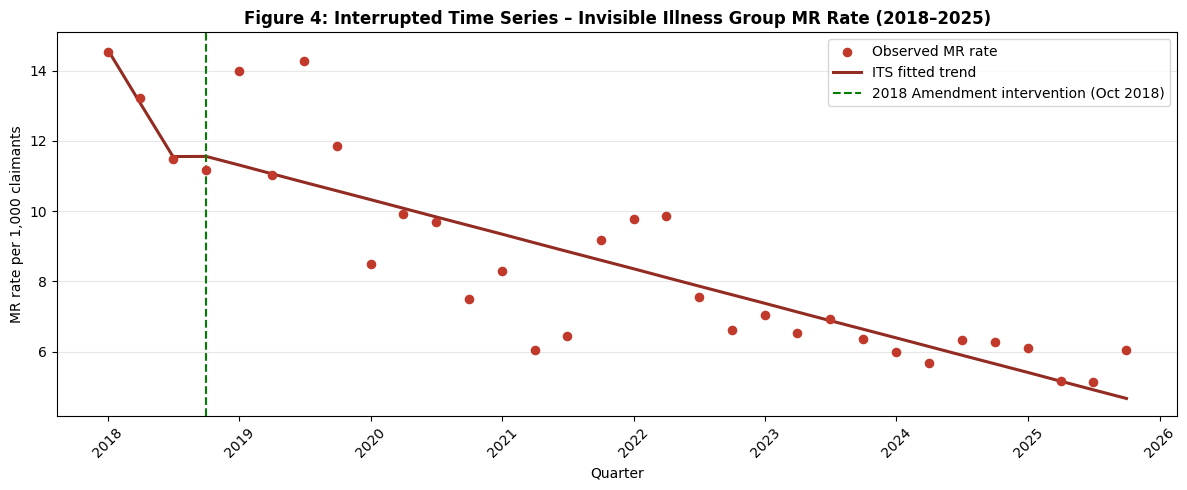

Figure 4 complete


In [ ]:
# FIGURE 4 — ITS PLOT WITH 2018 INTERVENTION
# ══════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(12,5))
ax.scatter(series.index, y, color='#C0392B', s=35, zorder=5,
           label='Observed MR rate')
ax.plot(series.index, y_pred, color='#922B21', lw=2.2,
        label='ITS fitted trend')
ax.axvline(intv, color='green', ls='--', lw=1.5,
           label='2018 Amendment intervention (Oct 2018)')
ax.set_title('Figure 4: Interrupted Time Series – Invisible Illness Group MR Rate (2018–2025)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Quarter')
ax.set_ylabel('MR rate per 1,000 claimants')
ax.legend()
ax.tick_params(axis='x', rotation=45)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('Figure4_ITS.png', dpi=180, bbox_inches='tight')
plt.show()
print("Figure 4 complete")


In [ ]:
# FULL DESCRIPTIVE SUMMARY TABLE
# ══════════════════════════════════════════════════════════════════════════════
print("\n=== DESCRIPTIVE STATISTICS SUMMARY (2018-2025) ===")
print(f"{'Metric':<45} {'Invisible':>15} {'Visible':>12}")
print("-"*74)
print(f"{'Mean quarterly caseload':<45} {inv_c.mean():>15,.0f} {vis_c.mean():>12,.0f}")
print(f"{'Mean MR rate per 1,000':<45} {inv_mr_rate.mean():>15.2f} {vis_mr_rate.mean():>12.2f}")
print(f"{'Mean clearance rate per 1,000':<45} {inv_cl_rate.mean():>15.2f} {vis_cl_rate.mean():>12.2f}")
print(f"{'Total MR clearances 2018-2025':<45} {inv_m_tot:>15,.0f} {vis_m_tot:>12,.0f}")
print(f"{'Total clearances 2018-2025':<45} {inv_l_tot:>15,.0f} {vis_l_tot:>12,.0f}")
print(f"{'Chi-sq MR p-value':<45} {'p<0.001':>15} {'-':>12}")
print(f"{'Odds Ratio MR':<45} {or_mr:>15.3f} {'-':>12}")
print(f"{'Chi-sq clearance p-value':<45} {'p<0.001':>15} {'-':>12}")
print(f"{'Odds Ratio clearance':<45} {or_cl:>15.3f} {'-':>12}")

print("\nALL ANALYSIS COMPLETE 2018-2025")
print("Download your 4 figures from the folder panel on the left.")




=== DESCRIPTIVE STATISTICS SUMMARY (2018-2025) ===
Metric                                              Invisible      Visible
--------------------------------------------------------------------------
Mean quarterly caseload                             2,001,099      544,688
Mean MR rate per 1,000                                   8.58         6.99
Mean clearance rate per 1,000                           19.35        17.07
Total MR clearances 2018-2025                         514,179      114,592
Total clearances 2018-2025                          1,204,345      282,440
Chi-sq MR p-value                                     p<0.001            -
Odds Ratio MR                                           1.223            -
Chi-sq clearance p-value                              p<0.001            -
Odds Ratio clearance                                    1.164            -

ALL ANALYSIS COMPLETE 2018-2025
Download your 4 figures from the folder panel on the left.
